# Final Mini Project: Evaluating and Improving an NLP Model
## Using the IMDB Movie Reviews Dataset

---

## Introduction

In this project, I am going to do sentiment analysis on movie reviews. Sentiment analysis means we look at a text and try to find out if the feeling in that text is positive or negative. This is one of the common tasks in NLP (Natural Language Processing).

I used the IMDB Movie Reviews dataset for this project. This dataset has 50,000 movie reviews and each review has a label that says either positive or negative. I got this dataset from Kaggle website. The file name is IMDB Dataset.csv.

In this project, I will first clean the text data, then convert it into numbers using TF-IDF method, then train three machine learning models which are Naive Bayes, Logistic Regression, and SVM. After training, I will check how well each model works and also look at the errors to understand what went wrong.

---
## Import Libraries

In [10]:
# Importing Standard Libraries
import re                        # Regular expressions for text cleaning
import warnings
warnings.filterwarnings('ignore')

# Data Handling
import pandas as pd              # DataFrame operations
import numpy as np               # Numerical operations

# Visualization
import matplotlib.pyplot as plt  # Plotting confusion matrices and charts
import seaborn as sns            # Heatmap for confusion matrix

# NLP: NLTK
import nltk
nltk.download('stopwords', quiet=True)   # English stopwords list
nltk.download('wordnet', quiet=True)     # WordNet for lemmatization
nltk.download('punkt', quiet=True)       # Tokenizer
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer  # Lemmatizer

# Feature Extraction
from sklearn.feature_extraction.text import TfidfVectorizer

# Model Training
from sklearn.naive_bayes import MultinomialNB          # Naive Bayes
from sklearn.linear_model import LogisticRegression    # Logistic Regression
from sklearn.svm import LinearSVC                      # SVM (linear, fast)

# Model Evaluation
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

print("All libraries imported successfully.")

All libraries imported successfully.


---
## 1. Dataset Preparation

First I loaded the dataset from the CSV file. The dataset has two columns. One column is called review and it contains the movie review text. Another column is called sentiment and it tells us if the review is positive or negative. There are 50,000 rows in total, with 25,000 positive reviews and 25,000 negative reviews. So the dataset is balanced which is good because we do not need to worry about class imbalance problem.

I also checked for missing values and there were none, so I did not need to do any extra cleaning for missing data. Below I displayed the first 5 records to see how the data looks.

In [11]:
# Load Dataset
# Make sure 'IMDB Dataset.csv' is in the same folder as this notebook
df = pd.read_csv("/content/IMDB Dataset.csv")

# Dataset Size
print(f"Dataset Shape: {df.shape}")
print(f"Total Reviews : {len(df):,}")
print(f"Columns       : {list(df.columns)}")

# Check Missing Values
print("\nMissing Values:")
print(df.isnull().sum())

# Class Distribution
print("\nSentiment Distribution:")
print(df['sentiment'].value_counts())

# Display First 5 Records
print("\nFirst 5 Sample Records:")
df.head()

Dataset Shape: (50000, 2)
Total Reviews : 50,000
Columns       : ['review', 'sentiment']

Missing Values:
review       0
sentiment    0
dtype: int64

Sentiment Distribution:
sentiment
positive    25000
negative    25000
Name: count, dtype: int64

First 5 Sample Records:


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


---
## 2. Text Preprocessing

Before training any model, we need to clean the text first. Raw text has many things that are not useful for the model, like punctuation, numbers, HTML tags, and very common words. So I wrote a function to clean each review step by step.

The first step is to convert all letters to lowercase. This is important because words like 'Good' and 'good' should be treated the same. The second step is to remove HTML tags because many IMDB reviews have tags like br which are not useful. The third step is to remove punctuation and special characters. After that I removed extra spaces.

Then I removed stopwords. Stopwords are very common English words like 'the', 'is', 'and' that do not give much meaning for sentiment. I also removed short words that have 2 letters or less because they are usually not useful.

The last step is lemmatization. Lemmatization changes a word to its base form, for example 'running' becomes 'run'. This helps reduce the vocabulary size and makes the features more consistent. I used WordNetLemmatizer from NLTK library for this.

In [12]:
# Initialize Tools
stop_words = set(stopwords.words('english'))  # Load English stopwords
lemmatizer = WordNetLemmatizer()              # Initialize lemmatizer

def preprocess_text(text):
    """
    Full text preprocessing pipeline:
    1. Lowercase
    2. Remove HTML tags (common in IMDB dataset)
    3. Remove punctuation and special characters
    4. Remove extra whitespace
    5. Tokenize by splitting on whitespace
    6. Remove stopwords and short tokens (len <= 2)
    7. Lemmatize each token
    8. Rejoin into a single cleaned string
    """
    # Step 1: Convert to lowercase
    text = text.lower()

    # Step 2: Remove HTML tags (e.g., <br />, <p>)
    text = re.sub(r'<[^>]+>', ' ', text)

    # Step 3: Remove punctuation and special characters (keep only letters)
    text = re.sub(r'[^a-z\s]', ' ', text)

    # Step 4: Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    # Step 5: Tokenize (split into individual words)
    tokens = text.split()

    # Step 6 & 7: Remove stopwords, short tokens, and lemmatize
    tokens = [
        lemmatizer.lemmatize(word)
        for word in tokens
        if word not in stop_words and len(word) > 2
    ]

    # Step 8: Rejoin tokens into a clean string
    return ' '.join(tokens)


# Apply Preprocessing to All Reviews
print("Preprocessing text data — this may take a minute...")
df['clean_review'] = df['review'].apply(preprocess_text)
print("Preprocessing complete.")

# Show Before vs After Comparison
print("\n── Before vs After Preprocessing (Sample) ──")
for i in range(3):
    print(f"\n[Review {i+1}]")
    print(f"  ORIGINAL : {df['review'].iloc[i][:150]}...")
    print(f"  CLEANED  : {df['clean_review'].iloc[i][:150]}...")

Preprocessing text data — this may take a minute...
Preprocessing complete.

── Before vs After Preprocessing (Sample) ──

[Review 1]
  ORIGINAL : One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with...
  CLEANED  : one reviewer mentioned watching episode hooked right exactly happened first thing struck brutality unflinching scene violence set right word trust sho...

[Review 2]
  ORIGINAL : A wonderful little production. <br /><br />The filming technique is very unassuming- very old-time-BBC fashion and gives a comforting, and sometimes d...
  CLEANED  : wonderful little production filming technique unassuming old time bbc fashion give comforting sometimes discomforting sense realism entire piece actor...

[Review 3]
  ORIGINAL : I thought this was a wonderful way to spend time on a too hot summer weekend, sitting in the air conditioned theater and watching a light-hearted come...
  CLEAN

---
## 3. Feature Extraction

Machine learning models cannot read text directly. We need to convert text into numbers first. For this project I used TF-IDF vectorization method.

TF-IDF stands for Term Frequency and Inverse Document Frequency. TF means how many times a word appears in one document. IDF means how rare or common the word is across all documents. If a word appears in many documents it gets a lower score. If a word appears in only a few documents it gets a higher score. This is useful because common words like 'movie' or 'film' will have low weight and words that are more specific to sentiment like 'brilliant' or 'boring' will have higher weight.

I set max_features to 5000 so the model only keeps the top 5000 most important words. I also used ngram_range of 1 to 2 which means the model considers both single words and pairs of words. This helps capture some context, for example 'not good' is different from just 'good'. I split the data into 80 percent for training and 20 percent for testing before applying TF-IDF.

In [13]:
# Encode Labels
# Convert text labels to binary integers: positive=1, negative=0
df['label'] = df['sentiment'].map({'positive': 1, 'negative': 0})

# Train-Test Split
# 80% training, 20% testing — random_state ensures reproducibility
X_train, X_test, y_train, y_test = train_test_split(
    df['clean_review'],   # Input: cleaned reviews
    df['label'],          # Output: sentiment labels
    test_size=0.2,        # 20% held out for testing
    random_state=42       # Fixed seed for reproducibility
)

print(f"Training samples : {len(X_train):,}")
print(f"Testing  samples : {len(X_test):,}")

# TF-IDF Vectorization
tfidf = TfidfVectorizer(
    max_features=5000,     # Limit vocabulary to top 5,000 terms
    ngram_range=(1, 2),    # Use unigrams AND bigrams for richer context
    sublinear_tf=True      # Apply log(1 + tf) to dampen high-frequency terms
)

# Fit on training data only, then transform both splits
X_train_tfidf = tfidf.fit_transform(X_train)   # Learn vocabulary + transform
X_test_tfidf  = tfidf.transform(X_test)        # Transform only (no fitting)

print(f"\nTF-IDF Matrix Shape (Train) : {X_train_tfidf.shape}")
print(f"TF-IDF Matrix Shape (Test)  : {X_test_tfidf.shape}")
print(f"Vocabulary Size             : {len(tfidf.vocabulary_):,} features")

# Show sample top TF-IDF terms
feature_names = tfidf.get_feature_names_out()
print(f"\nSample vocabulary terms: {list(feature_names[:10])}")

Training samples : 40,000
Testing  samples : 10,000

TF-IDF Matrix Shape (Train) : (40000, 5000)
TF-IDF Matrix Shape (Test)  : (10000, 5000)
Vocabulary Size             : 5,000 features

Sample vocabulary terms: ['abandoned', 'abc', 'ability', 'able', 'absence', 'absent', 'absolute', 'absolutely', 'absolutely nothing', 'absurd']


---
## 4. Model Training

I trained three different machine learning models to compare their performance.

The first model is Naive Bayes. This model uses probability to classify text. It is based on Bayes theorem and it assumes that each word is independent from the others. This is a simple and fast model and it works quite well for text classification. I used alpha equal to 1.0 which is the Laplace smoothing to avoid zero probability problem.

The second model is Logistic Regression. This model learns the weight of each word to decide if the review is positive or negative. It uses a sigmoid function to give a probability output. This model is more powerful than Naive Bayes because it can learn from the relationships between features.

The third model is SVM which stands for Support Vector Machine. I used LinearSVC which is a fast version of SVM that works well for high dimensional data like TF-IDF vectors. SVM tries to find the best line or boundary that separates positive and negative reviews. It usually gives good results for text classification tasks.

In [14]:
# Defining Models
models = {
    'Naive Bayes': MultinomialNB(
        alpha=1.0          # Laplace smoothing factor (alpha=1 = add-one smoothing)
    ),
    'Logistic Regression': LogisticRegression(
        max_iter=1000,     # Allow enough iterations to converge
        random_state=42,
        C=1.0              # Regularization strength (higher = less regularization)
    ),
    'SVM': LinearSVC(
        max_iter=2000,     # More iterations for convergence on large datasets
        random_state=42,
        C=1.0
    )
}

# Train All Models
trained_models = {}
predictions    = {}

for name, model in models.items():
    print(f"Training: {name}...")
    model.fit(X_train_tfidf, y_train)          # Train on TF-IDF training features
    preds = model.predict(X_test_tfidf)        # Predict on test set
    trained_models[name] = model
    predictions[name]    = preds
    print(f"  Done. Test Accuracy: {accuracy_score(y_test, preds):.4f}")

print("\nAll models trained successfully.")

Training: Naive Bayes...
  Done. Test Accuracy: 0.8622
Training: Logistic Regression...
  Done. Test Accuracy: 0.8934
Training: SVM...
  Done. Test Accuracy: 0.8845

All models trained successfully.


---
## 5. Model Evaluation

After training, I evaluated each model using four main metrics. These metrics help us understand how well the model is working.

Accuracy is the simplest metric. It shows the percentage of correct predictions out of all predictions. Precision shows how many of the reviews that the model predicted as positive are actually positive. Recall shows how many of the actual positive reviews the model was able to find correctly. F1-score is the balance between precision and recall. It is useful when we want to consider both at the same time.

I also printed the full classification report for each model which shows these numbers separately for both positive and negative class. Below you can see the results for all three models.

In [15]:
# Compute Metrics for Each Model
results = []

for name, preds in predictions.items():
    acc  = accuracy_score (y_test, preds)
    prec = precision_score(y_test, preds, average='weighted')
    rec  = recall_score   (y_test, preds, average='weighted')
    f1   = f1_score       (y_test, preds, average='weighted')

    results.append({
        'Model'    : name,
        'Accuracy' : round(acc,  4),
        'Precision': round(prec, 4),
        'Recall'   : round(rec,  4),
        'F1-Score' : round(f1,   4)
    })

# Display Comparison Table
results_df = pd.DataFrame(results)
print("═" * 65)
print("          MODEL PERFORMANCE COMPARISON")
print("═" * 65)
print(results_df.to_string(index=False))
print("═" * 65)

# Highlight best model
best_model = results_df.loc[results_df['F1-Score'].idxmax(), 'Model']
print(f"\n★ Best Model by F1-Score: {best_model}")

# Full Classification Reports
for name, preds in predictions.items():
    print(f"\n── Classification Report: {name} ──")
    print(classification_report(
        y_test, preds,
        target_names=['Negative (0)', 'Positive (1)']
    ))

═════════════════════════════════════════════════════════════════
          MODEL PERFORMANCE COMPARISON
═════════════════════════════════════════════════════════════════
              Model  Accuracy  Precision  Recall  F1-Score
        Naive Bayes    0.8622     0.8624  0.8622    0.8622
Logistic Regression    0.8934     0.8935  0.8934    0.8934
                SVM    0.8845     0.8845  0.8845    0.8845
═════════════════════════════════════════════════════════════════

★ Best Model by F1-Score: Logistic Regression

── Classification Report: Naive Bayes ──
              precision    recall  f1-score   support

Negative (0)       0.87      0.85      0.86      4961
Positive (1)       0.86      0.87      0.86      5039

    accuracy                           0.86     10000
   macro avg       0.86      0.86      0.86     10000
weighted avg       0.86      0.86      0.86     10000


── Classification Report: Logistic Regression ──
              precision    recall  f1-score   support

Negati

---
## 6. Confusion Matrix Visualization

A confusion matrix shows how many predictions the model got right and wrong. It has four values. True Positive means the model predicted positive and the real label is also positive. True Negative means the model predicted negative and the real label is also negative. False Positive means the model predicted positive but the real label is negative. False Negative means the model predicted negative but the real label is positive.

I created confusion matrix visualization for all three models side by side so it is easy to compare them. I also made a bar chart to compare all the metrics together.

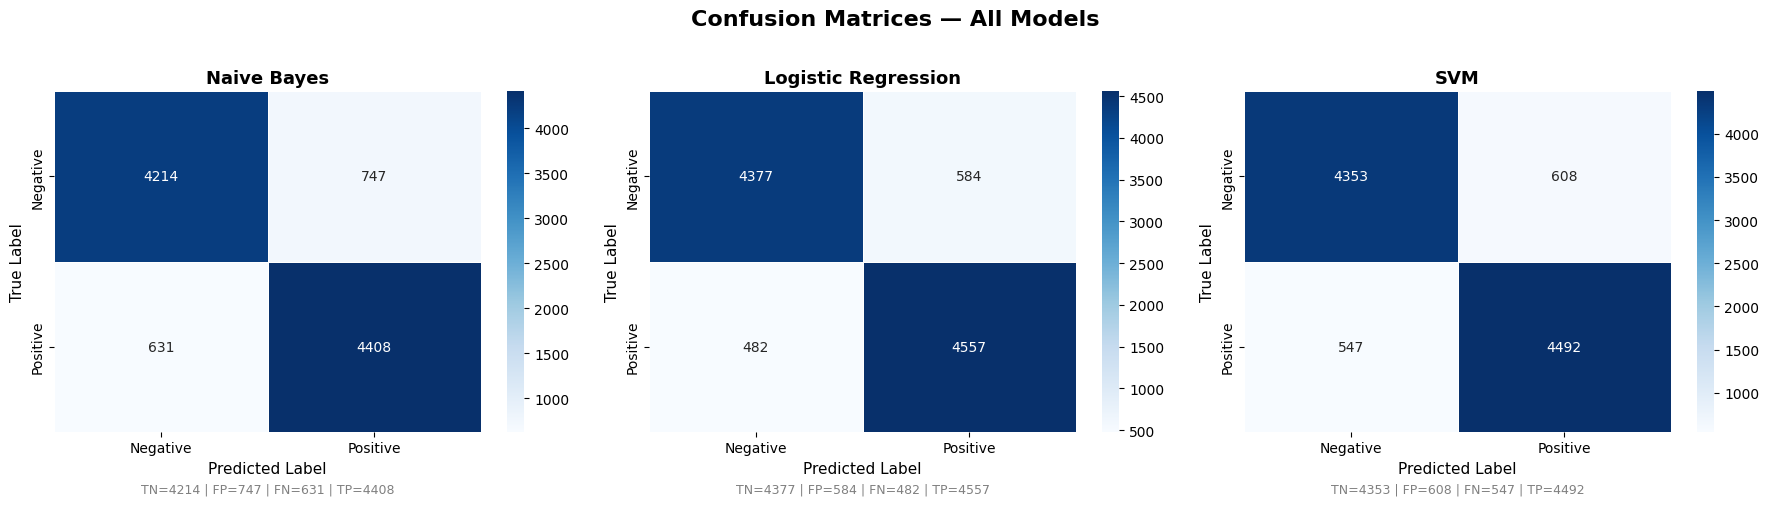

Confusion matrices saved as 'confusion_matrices.png'


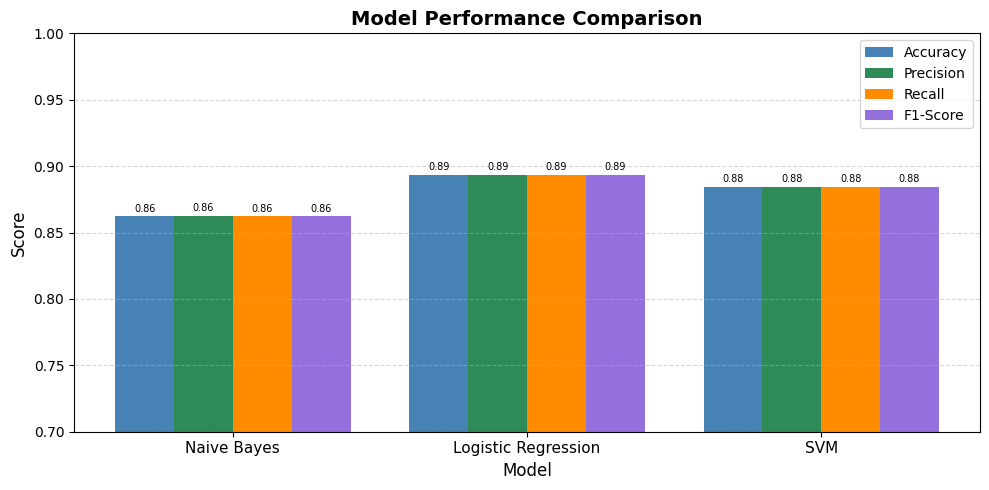

Model comparison chart saved as 'model_comparison.png'


In [16]:
# Plot Confusion Matrices for All Three Models
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Confusion Matrices — All Models', fontsize=16, fontweight='bold', y=1.02)

class_labels = ['Negative', 'Positive']

for ax, (name, preds) in zip(axes, predictions.items()):
    cm = confusion_matrix(y_test, preds)   # Compute confusion matrix

    # Plot heatmap using seaborn
    sns.heatmap(
        cm,
        annot=True,           # Show numbers in each cell
        fmt='d',              # Integer format
        cmap='Blues',         # Blue color scale
        xticklabels=class_labels,
        yticklabels=class_labels,
        ax=ax,
        linewidths=0.5
    )

    ax.set_title(name, fontsize=13, fontweight='bold')
    ax.set_xlabel('Predicted Label', fontsize=11)
    ax.set_ylabel('True Label', fontsize=11)

    # Annotate TP / TN / FP / FN positions
    ax.text(0.5, -0.18,
        f"TN={cm[0,0]} | FP={cm[0,1]} | FN={cm[1,0]} | TP={cm[1,1]}",
        ha='center', transform=ax.transAxes, fontsize=9, color='gray')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print("Confusion matrices saved as 'confusion_matrices.png'")

# Metric Bar Chart Comparison
fig2, ax2 = plt.subplots(figsize=(10, 5))

x = np.arange(len(results_df['Model']))  # Model positions
width = 0.2                              # Bar width

bars1 = ax2.bar(x - 1.5*width, results_df['Accuracy'],  width, label='Accuracy',  color='steelblue')
bars2 = ax2.bar(x - 0.5*width, results_df['Precision'], width, label='Precision', color='seagreen')
bars3 = ax2.bar(x + 0.5*width, results_df['Recall'],    width, label='Recall',    color='darkorange')
bars4 = ax2.bar(x + 1.5*width, results_df['F1-Score'],  width, label='F1-Score',  color='mediumpurple')

ax2.set_xlabel('Model', fontsize=12)
ax2.set_ylabel('Score', fontsize=12)
ax2.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(results_df['Model'], fontsize=11)
ax2.set_ylim(0.7, 1.0)   # Focus on relevant range
ax2.legend(fontsize=10)
ax2.grid(axis='y', linestyle='--', alpha=0.5)

# Add value labels on each bar
for bars in [bars1, bars2, bars3, bars4]:
    for bar in bars:
        ax2.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.002,
            f'{bar.get_height():.2f}',
            ha='center', va='bottom', fontsize=7
        )

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Model comparison chart saved as 'model_comparison.png'")

---
## 7. Error Analysis

Error analysis means we look at the wrong predictions and try to understand why the model made mistakes. This helps us find the weaknesses of the model and think about how to improve it.

I used the SVM model for error analysis because it was the best performing model. I collected all the wrong predictions and separated them into false positives and false negatives. I also looked at the review length to see if shorter reviews are harder to classify.

In [17]:
# Error Analysis: Focus on Best Model (SVM)
# We use SVM predictions for detailed error analysis

best_preds = predictions['SVM']

# Collect Misclassified Samples
# Reset index for alignment
X_test_reset = X_test.reset_index(drop=True)
y_test_reset = y_test.reset_index(drop=True)

# Build a results DataFrame
error_df = pd.DataFrame({
    'clean_review'  : X_test_reset,
    'true_label'    : y_test_reset,
    'svm_prediction': best_preds
})

# Filter only incorrect predictions
errors = error_df[error_df['true_label'] != error_df['svm_prediction']].copy()

# Map numeric labels back to text for readability
label_map = {1: 'positive', 0: 'negative'}
errors['true_label']     = errors['true_label'].map(label_map)
errors['svm_prediction'] = errors['svm_prediction'].map(label_map)

print(f"Total test samples     : {len(error_df):,}")
print(f"Misclassified samples  : {len(errors):,}")
print(f"Error rate             : {len(errors)/len(error_df)*100:.2f}%")

# Error Type Breakdown
# False Positives: Predicted positive, actually negative
false_positives = errors[errors['svm_prediction'] == 'positive']
# False Negatives: Predicted negative, actually positive
false_negatives = errors[errors['svm_prediction'] == 'negative']

print(f"\nFalse Positives (predicted +, actually -) : {len(false_positives):,}")
print(f"False Negatives (predicted -, actually +) : {len(false_negatives):,}")

# Display Sample Misclassified Reviews
print("\n── Sample False Positives (Model thought positive, was actually negative) ──")
for i, row in false_positives.head(5).iterrows():
    print(f"  → {row['clean_review'][:120]}...")
    print(f"     True: {row['true_label']} | Predicted: {row['svm_prediction']}\n")

print("── Sample False Negatives (Model thought negative, was actually positive) ──")
for i, row in false_negatives.head(5).iterrows():
    print(f"  → {row['clean_review'][:120]}...")
    print(f"     True: {row['true_label']} | Predicted: {row['svm_prediction']}\n")

Total test samples     : 10,000
Misclassified samples  : 1,155
Error rate             : 11.55%

False Positives (predicted +, actually -) : 608
False Negatives (predicted -, actually +) : 547

── Sample False Positives (Model thought positive, was actually negative) ──
  → enjoy seeing must started hour movie unconnected burst unwatchability love film otherwise wonder could made film somethi...
     True: negative | Predicted: positive

  → although series mini film particular important time release feel series whole actually fairly poorly written weak cast i...
     True: negative | Predicted: positive

  → fact part liked lot interesting twist left seen feeling saw movie granted ending different typical saw let face group gu...
     True: negative | Predicted: positive

  → imagine every state nay every country exactly tree growing ground foliage imagine also monkey trapper camp far beaten tr...
     True: negative | Predicted: positive

  → keen pallbearer bad slow time movie go get

── Review Length Analysis ──
  Average length — Correctly classified   : 117.3 words
  Average length — Incorrectly classified : 114.5 words
  → Shorter reviews tend to have less context → harder to classify correctly


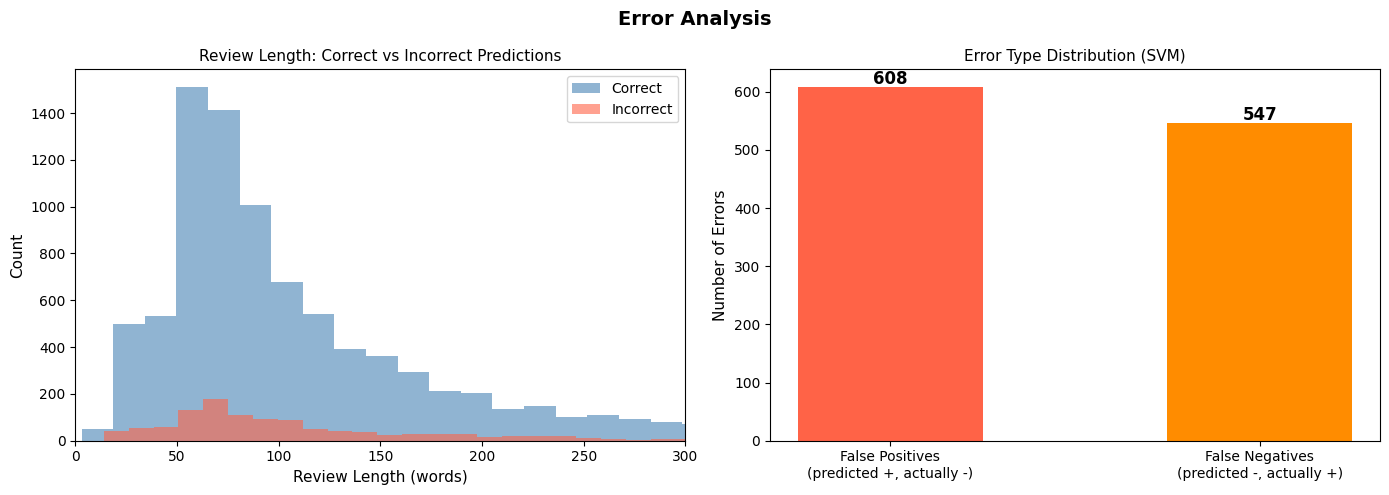

Error analysis chart saved as 'error_analysis.png'


In [18]:
# Review Length Analysis
# Check if shorter reviews are harder to classify correctly

# Add review length column
error_df['review_length'] = error_df['clean_review'].apply(lambda x: len(x.split()))
error_df['is_error']      = (error_df['true_label'] != error_df['svm_prediction']).astype(int)

# Average length: correct vs incorrect
avg_correct   = error_df[error_df['is_error'] == 0]['review_length'].mean()
avg_incorrect = error_df[error_df['is_error'] == 1]['review_length'].mean()

print("── Review Length Analysis ──")
print(f"  Average length — Correctly classified   : {avg_correct:.1f} words")
print(f"  Average length — Incorrectly classified : {avg_incorrect:.1f} words")
print(f"  → Shorter reviews tend to have less context → harder to classify correctly")

# Plot: Error Distribution by Review Length
fig3, (ax3a, ax3b) = plt.subplots(1, 2, figsize=(14, 5))
fig3.suptitle('Error Analysis', fontsize=14, fontweight='bold')

# Left plot: Review length distribution (correct vs incorrect)
correct_lengths   = error_df[error_df['is_error'] == 0]['review_length']
incorrect_lengths = error_df[error_df['is_error'] == 1]['review_length']

ax3a.hist(correct_lengths,   bins=40, alpha=0.6, color='steelblue',  label='Correct')
ax3a.hist(incorrect_lengths, bins=40, alpha=0.6, color='tomato',     label='Incorrect')
ax3a.set_xlabel('Review Length (words)', fontsize=11)
ax3a.set_ylabel('Count', fontsize=11)
ax3a.set_title('Review Length: Correct vs Incorrect Predictions', fontsize=11)
ax3a.legend()
ax3a.set_xlim(0, 300)

# Right plot: Error type bar chart (FP vs FN)
error_types  = ['False Positives\n(predicted +, actually -)',
                'False Negatives\n(predicted -, actually +)']
error_counts = [len(false_positives), len(false_negatives)]
colors       = ['tomato', 'darkorange']

bars = ax3b.bar(error_types, error_counts, color=colors, width=0.5)
ax3b.set_title('Error Type Distribution (SVM)', fontsize=11)
ax3b.set_ylabel('Number of Errors', fontsize=11)

# Add count labels
for bar, count in zip(bars, error_counts):
    ax3b.text(bar.get_x() + bar.get_width()/2,
              bar.get_height() + 5,
              str(count), ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('error_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Error analysis chart saved as 'error_analysis.png'")

### Error Analysis Findings

After looking at the wrong predictions, I found some patterns in the errors.

One common problem is sarcasm. For example a review might say something like 'oh great, another boring movie' and the word 'great' makes the model think it is positive but actually the review is negative. The model cannot understand sarcasm because it only looks at individual words.

Another problem is negation. When someone says 'not good' the model sometimes still focuses on the word 'good' and predicts positive. Even though I used bigrams to help with this, it does not always work.

Some reviews have mixed feelings, for example 'the acting was great but the story was boring'. In this case it is hard to say if the overall sentiment is positive or negative. The model can get confused by this.

Short reviews are also difficult because they do not have enough words to help the model make a good decision.

To improve the model, I think we can try a few things. First we can add special negation handling where we mark words after 'not' or 'never' differently. Second we can try word embeddings like Word2Vec which can understand meaning better than TF-IDF. Third we can try deep learning models like BERT which can understand context and meaning much better. We can also try to tune the hyperparameters to see if we can get better results.

---
## 8. Conclusion

In this project I built a sentiment analysis system using the IMDB movie reviews dataset. I went through all the steps from loading the data, cleaning the text, extracting features, training models, and evaluating results.

For preprocessing I cleaned the text by removing HTML tags, punctuation, stopwords, and then applied lemmatization. This step is very important because cleaner text gives better features for the model.

For feature extraction I used TF-IDF with 5000 features and bigrams. This method gave a good representation of each review as a numeric vector.

I trained three models. Naive Bayes was the simplest and fastest but had lower accuracy compared to the others. Logistic Regression performed better than Naive Bayes. SVM gave the best results overall among the three models.

From the error analysis I learned that the models have difficulty with sarcasm, negation, mixed sentiment reviews, and short reviews. These are common problems in sentiment analysis and they are hard to solve with simple methods like TF-IDF.

In the future, I think using deep learning models like BERT would help a lot because BERT can understand the full context of a sentence. We could also try to get more training data or do better preprocessing to handle negation.

Overall this project helped me understand the full pipeline of NLP text classification from preprocessing to model evaluation.

## References

Dataset: IMDB Dataset of 50K Movie Reviews. Kaggle. https://www.kaggle.com/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews

Jurafsky, D. and Martin, J. H. Speech and Language Processing. https://web.stanford.edu/~jurafsky/slp3/

Scikit-learn documentation: https://scikit-learn.org/stable/

NLTK documentation: https://www.nltk.org/